In [256]:
import numpy as np
import pandas as pd
import os
import csv
import math
import matplotlib.pyplot as plt
import datetime as dt
from datetime import datetime, timedelta
%matplotlib inline
import plotly as py
import plotly.figure_factory as ff
from plotly.offline import init_notebook_mode,iplot
import plotly.graph_objects as go
#import cufflinks as cf
import plotly.offline
init_notebook_mode(connected=True)

In [257]:
def smoking_sesh(cp_data,puff_data):
    
    # extracting the smoking event start time and end time (i.e., the start of the first puff and the end of the last puff)
    smoking_start = cp_data.iloc[0]["starttime abs"]
    smoking_end = cp_data.iloc[-1]["endtime abs"]
    smoking_end = pd.to_datetime(smoking_end)

    # creating a time series seperated by 250 ms)
    smoking_ts = pd.date_range(start=smoking_start,end=smoking_end+pd.to_timedelta(1,unit='m'), freq='250ms')
    # creating a data frame and assining the times series as the index.
    # I am intilizing the label to be non smoking (i.e., 0)
    smoking = pd.DataFrame(index=smoking_ts)
    label_col = np.zeros(smoking.shape[0])
    puff_col = np.zeros(smoking.shape[0])
    vol_col = np.zeros(smoking.shape[0])
    
    
    
    
    # I will loop through each puff and change the label smokinf (i.e. 1)
    for puff_i in range(cp_data.shape[0]):
        index = (smoking_ts >= cp_data.iloc[puff_i]["starttime abs"]) & \
                         (smoking_ts <= cp_data.iloc[puff_i]["endtime abs"])
        
        y = puff_data[puff_data.columns[0]].dropna().values
        n = sum(index)
        y= signal.resample(y, n)
        
        vol_col[index]=y
        label_col[index] = 1
        puff_col[index] = puff_i + 1
    
    smoking['label'] = label_col.astype(int)
    smoking['puff'] = puff_col.astype(int)
    smoking['volume']=vol_col.astype(int)
    return smoking

In [258]:
# function for fancy plotting
def smoking_sesh_plots(smoking):
    color = '#9467bd'
    trace = go.Scatter(x = smoking.index, 
                       y = smoking["label"], 
                       name = "label", 
                       line = dict(color = color))
    data = [trace]
    layout = go.Layout( title = p+" Smoking Session",
                      yaxis = dict(title = "labels"),)
                       
    fig = go.Figure(data = data, layout = layout)
    fig.show()
    
    

In [263]:
main_dir = "../Data/Pilot/Clean"
all_p = ["P"+str(x) for x in range(3,8)]
# all_p = ["P0"]
for p in all_p:
    #getting clean cp_data
    clean_cp_path = os.path.join(main_dir,p,"CP.csv") 
    cp_data = pd.read_csv(clean_cp_path,index_col=0)
    
    puff_data = pd.read_csv("/Users/rma145/Desktop/thermo-smoking/Data/Pilot/Raw/P0/Puff.csv",index_col=0)
    
    
    smoking = smoking_sesh(cp_data,puff_data)
    
    #plotting the smoking session
    #smoking.plot() # this one is for regular plot
    smoking_sesh_plots(smoking) # this is for fancy plotting
    
    smoking.to_csv(os.path.join(main_dir,p,"CP_ts.csv"))

  

In [260]:
smoking

,label,puff,volume
2020-02-27 17:47:07.438,1,1,13
2020-02-27 17:47:07.688,1,1,31
2020-02-27 17:47:07.938,1,1,65
2020-02-27 17:47:08.188,1,1,68
2020-02-27 17:47:08.438,1,1,71
...,...,...,...
2020-02-27 17:52:06.188,0,0,0
2020-02-27 17:52:06.438,0,0,0
2020-02-27 17:52:06.688,0,0,0
2020-02-27 17:52:06.938,0,0,0


12

In [195]:
from scipy.integrate import simps
from scipy import signal

In [215]:
i=13
duration = cp_data.iloc[i-1]["Duration(ms)"]/1000
volume = puff_data[["Time","Puff "+str(i)]].dropna().values
x = volume[:,0]
y = volume[:,1]
print(np.trapz(y=y,x=x))
print(simps(y=y,x=x))

126.27000000000001
126.2765


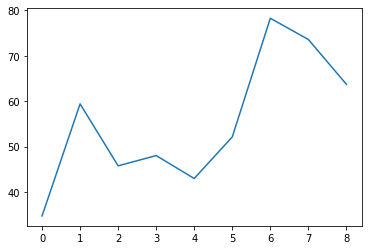

In [216]:
# down sample to 4 fps
n = smoking[smoking.puff==i].shape[0]
plt.plot(signal.resample(y, n))

In [189]:
duration

2.981

In [192]:
0.02 * 1000

20.0

In [194]:
len(x) / duration

48.97685340489769

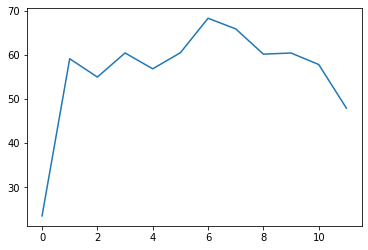